In [15]:
!git clone https://github.com/Liza228ko/DM2026-Assignment-1.git
%cd DM2026-Assignment-1

Cloning into 'DM2026-Assignment-1'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 90 (delta 16), reused 16 (delta 16), pack-reused 71 (from 2)
Receiving objects: 100% (90/90), 2.07 MiB | 24.61 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/DM2026-Assignment-1/DM2026-Assignment-1


In [16]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [17]:
%matplotlib inline
#%reload_ext autoreload
#%autoreload 2

In [18]:
from model.metrics import MSE, evaluate_linear_regression#, MAE
from model.gradients import MSE_grad#, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt

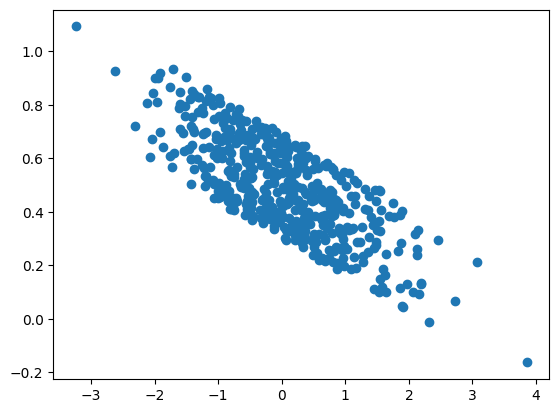

In [19]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [21]:
datasets = ['A', 'B', 'C', 'D']
learning_rate = [0.1, 0.01, 0.001]

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.013423623061455565, Val loss:0.012580010701461058
100. Training loss: 0.013423622480987135, Val loss:0.012580089713127157
150. Training loss: 0.013423622480987133, Val loss:0.012580089715050587
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


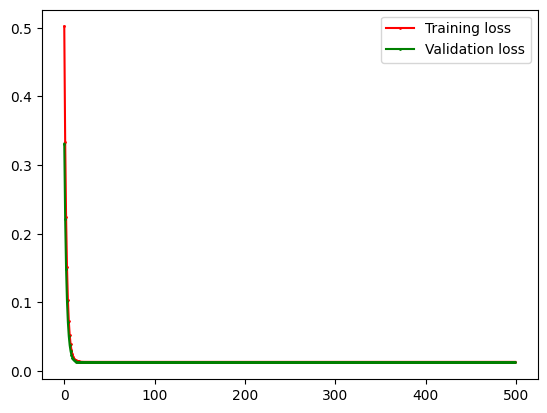

=== Linear Regression Evaluation ===


ValueError: Unknown format code 'f' for object of type 'str'

In [23]:
for ds in datasets:
  # Loading data
  loaded_data = np.load(f'data/linear_data/linear_data_{ds}.npz')

  X = loaded_data['X_data']
  y = loaded_data['y_data']
  W = loaded_data['W_data']

  # Show the size of data
  print(f"X size : {X.shape}, y size : {y.shape}")

  # Make sure size and dim correct.
  size = X.shape[0]
  dim = X.shape[1]-1

  # Train the model
  from model.linear_model import LinearModel

  seed = 42 # do not change the seed
  np.random.seed(seed)

  # Setting loss function and gradient.
  loss_fn = MSE
  grad_fn = MSE_grad

  # Split dataset to train dataset and validation dataset
  X_train,y_train,X_val,y_val = get_train_val(X,y)

  for lr in learning_rate:
    # Setting model and starting training
    model = LinearModel(dim,True,loss_fn,grad_fn)
    model.fit(X_train,y_train,lr,n_iteration =500,val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

    # Plot
    plt.scatter(X_val[:,1],y_val)
    plt.plot(X_val[:,1],y_val_pred)
    plt.show()



In [ ]:
# Get the Prediction


In [ ]:
# Evaluation
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
